# Optimization, Positive Definiteness, and Least Squares

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## Motivation

- Least squares is the canonical quadratic optimization problem in datascience, economics, and ML, and our first taste of optimization
- A quadratic has a unique minimum only if its Hessian is positive definite, so we start with curvature and definiteness
- Positive definite matrices also have a Cholesky decomposition, which solves the normal equations and turns a covariance matrix into correlated random draws
- Uniqueness of $\beta$ is what econometricians call identification
  - Collinear or underdetermined data breaks it, and `lstsq` will still return an answer
- Regularization adds curvature to restore a unique solution, at the cost of interpretation

## Extra Materials

- [scikit-learn ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

## Packages

This section uses the following packages:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from numpy.linalg import cond, matrix_rank, norm
from scipy.linalg import solve, eigvals, eigvalsh
from scipy.linalg import cholesky, solve_triangular
np.random.seed(526)

# Optimization and Curvature

## First and Second Order Conditions in Optimization

- For univariate unconstrained optimization $\min_x f(x)$
- The FONC was $f'(x) = 0$.
  - But this might not be a valid solution! Or there might be many
- The second order condition gives us more information and provides sufficient conditions
  - if $f''(x) > 0$, then $x$ is a local minimum; if $f''(x) < 0$, then $x$ is a local maximum.
  - if $f''(x) = 0$ then there may be multiple solutions (locally)

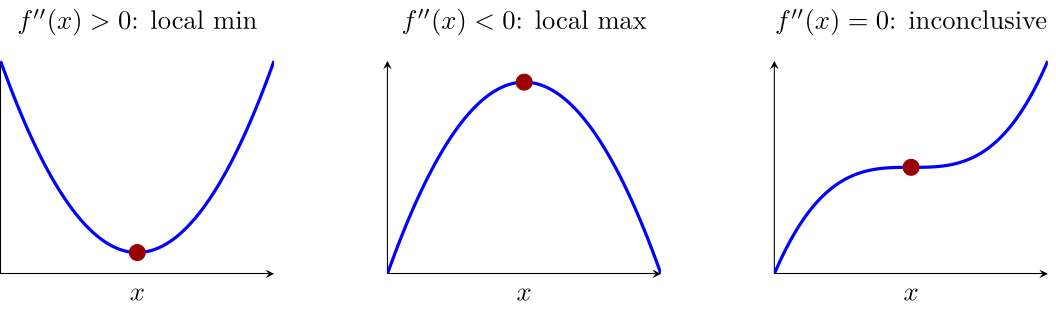

## Related Univariate Concepts

- Recall in your math prep that for a univariate function $f(x)$, we have:
  - $f(x)$ is **convex** if $f''(x) \geq 0$ for all $x$ in the domain.
  - $f(x)$ is **concave** if $f''(x) \leq 0$ for all $x$ in the domain.
  - $f(x)$ is **strictly convex** if $f''(x) > 0$ for all $x$ in the domain.
  - $f(x)$ is **strictly concave** if $f''(x) < 0$ for all $x$ in the domain.
- We will generalize these concepts for thinking about multivariate functions
  - Local behavior, $x'$ such that $|x - x'| < \epsilon$, for some $\epsilon$ “balls”

## Quadratic Functions in Higher Dimensions

- Recall univariate function $f(x) = \frac{a}{2} x^2 + b x + c$ for $x \in {\mathbb{R}}$.
- General quadratic for $x \in {\mathbb{R}}^N$ requires cross-terms ($a_{12} x_1 x_2, a_{11} x_1^2$ etc.) and linear terms (e.g, $b_1 x_1, b_2 x_2$)
- An example form is $f(x) = \frac{1}{2} x^{\top} A x + b^{\top} x + c$
  - For symmetric matrix $A$, vector $b$, and scalar $c$
  - Not unique, but this form gives convenient gradients and Hessians

## Gradients of Quadratic Forms

- Univariate: $f'(x) \equiv \nabla f(x) = a x + b$ and $f''(x) \equiv \nabla^2 f(x) = a$
- Multivariate: $\nabla f(x) = A x + b$ and $\nabla^2 f(x) = A$
  - $\nabla f(x)$ is the gradient vector at $x$
  - $\nabla^2 f(x)$ is the Hessian matrix at $x$
  - Quadratic forms are special since the Hessian is constant (not $x$ dependent)
- The Hessian is the symmetric matrix $A$, so the curvature of a quadratic is a property of that matrix: its definiteness

# Positive Definite Matrices

## Positive Definite Matrices

- A symmetric matrix $A$ is positive definite if $x^{\top} A x > 0$ for all $x \neq 0$
- Useful in many areas, such as covariance matrices. Example

In [4]:
A = np.array([[1, 2],
              [2, 5]])
x = np.array([0, 1]) # can't really check for all x
print(f"x^T A x = {x.T @ A @ x}")

x^T A x = 5

- Example of a symmetric matrix that is not positive definite

In [5]:
A = np.array([[1, 2],
              [2, 0]])
print(f"x^T A x = {x.T @ A @ x}")  # one counterexample is enough

x^T A x = 0

- We can check these with eigenvalues

## Checking Definiteness with Eigenvalues

- You cannot check $x^{\top} A x > 0$ for all $x$. Instead check whether the “stretching” is positive in every eigenvector direction
- Symmetric $A$ is positive definite iff all eigenvalues are strictly positive, and positive semi-definite iff all are weakly positive
  - `eigvalsh` is specialized for symmetric matrices and returns real eigenvalues
  - A positive semi-definite matrix that is not positive definite has a zero eigenvalue, so it is singular

In [6]:
A_eigs = eigvalsh(np.array([[1, 2],
                            [2, 5]]))
print(f"eigs = {A_eigs}, pos-def? {np.all(A_eigs > 0)}")
A_eigs = eigvalsh(np.array([[1, 0],
                            [0, 0]]))
print(f"eigs = {A_eigs}, pos-def? {np.all(A_eigs > 0)}, \
pos-semi-def? {np.all(A_eigs >= 0)}")

eigs = [0.17157288 5.82842712], pos-def? True
eigs = [0. 1.], pos-def? False, pos-semi-def? True

## Negative Definite Matrices

- Negative definite flips the inequalities: all eigenvalues strictly (weakly) negative for negative (semi-)definite. Think of a concave vs. convex function

In [7]:
A = -1 * np.array([[3, -0.1],
                   [-0.1, 2]])
A_eigs = eigvalsh(A)
print(A_eigs)
is_negative_definite = np.all(A_eigs < 0)
is_negative_semi_definite = np.all(A_eigs <= 0) # or A_eigs <= eps
print(f"neg-def? {is_negative_definite}, neg-semi-def? {is_negative_semi_definite}")

[-3.00990195 -1.99009805]
neg-def? True, neg-semi-def? True

## Negative Semi-Definite Matrix

- Semi-definite, but not definite requires the matrix to not be full rank
- At least one zero eigenvalue is necessary and sufficient for a matrix to be singular

In [8]:
A = np.array([[-1, -1],
              [-1, -1]])
A_eigs = eigvalsh(A)
print(A_eigs)
is_negative_definite = np.all(A_eigs < 0)
is_negative_semi_definite = np.all(A_eigs <= 0) # or A_eigs <= eps
print(f"neg-def? {is_negative_definite}, neg-semi-def? {is_negative_semi_definite}")

[-2.  0.]
neg-def? False, neg-semi-def? True

## Indefinite Matrices

- If a matrix has both positive and negative eigenvalues, it is indefinite
- For example,

In [9]:
A = np.array([[1, -1],
              [-1, -1]])
A_eigs = eigvalsh(A)
print(A_eigs)

[-1.41421356  1.41421356]

## Necessary and Sufficient Conditions for Optimization

- The FONC of $\min_{x}\left\{\tfrac{1}{2} x^{\top}A x + b^{\top} x + c\right\}$ is
  - $\nabla f(x^*) = A x^* + b = \mathbf{0}$
  - If invertible, then $x^* = -A^{-1} b$, where uniqueness will be related to identification
  - Same condition for minimization and maximization?
- Need second order sufficient condition in general to check min vs. max vs. neither
  - $\nabla^2 f(x^*)$ is positive definite for a unique minimum, semi-definite for a minima with local multiplicity where some directions are “flat”
  - Replace with negative definite/semi-definite for maxima
  - If neither, then $x^*$ is neither a minimum nor a maximum (e.g., a saddle point)

## Strict Concavity/Convexity

- Quadratic functions have the same curvature everywhere, so not $x$ dependent
- Univariate:
  - $a > 0$ is strict convexity
  - $a < 0$ is strict concavity
  - $a = 0$ is linear (neither)
- Multivariate:
  - $A$ is positive definite is strict convexity, $A$ is negative definite is strict concavity.
  - $A$ is semi-definite weakly convex (maybe strictly in some “directions”)
  - And vice-versa for concavity
- Recall that the univariate is nested: $A = \begin{bmatrix}a\end{bmatrix}$ with eigenvalue $a$

## Example of Constructing Quadratic Form

- For $f(x_1, x_2) = -3 x_1^2 + x_1 x_2 - \tfrac{1}{2} x_2^2 + x_2 + 5$.
- Let $x \equiv \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$ and use canonical $f(x)=\tfrac{1}{2} x^{\top} A x + b^{\top} x + c$.
  - Then $A \equiv \begin{bmatrix} -6 & 1 \\ 1 & -1 \end{bmatrix}$ (negative definite), $b \equiv \begin{bmatrix} 0 \\ 1 \end{bmatrix}$, and $c \equiv 5$.
  - Gradient: $\nabla f(x) = A x + b = \begin{bmatrix} -6 x_1 + x_2 \\ x_1 - x_2 + 1 \end{bmatrix}$.
  - Hessian: $\nabla^2 f(x) = A$.

eigs(A) = [-6.1925824 -0.8074176]
neg-def? True

## Indefinite Example

- $f(x_1, x_2) = -3 x_1^2 + x_1 x_2 + x_2 + 5$
  - $A = \begin{bmatrix} -6 & 1 \\ 1 & 0 \end{bmatrix}$, $b = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$, and $c = 5$

In [11]:
A = np.array([[-6, 1],
              [1, 0]])
A_eigs = eigvalsh(A)
print(f"eigs(A) = {A_eigs}")

eigs(A) = [-6.16227766  0.16227766]

## Shape of Positive Definite Function

- For $A = \begin{bmatrix} 3 & 1 \\ 1 & 2\end{bmatrix}$
- This has a **unique minima** (at $(0, 0)$, since no “affine” term, $b$)

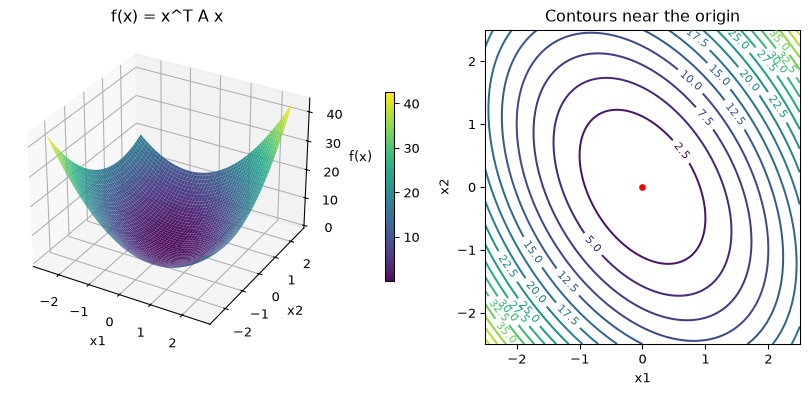

## Shape of Negative Semi-Definite Function

- For our $A = \begin{bmatrix} -1 & -1 \\ -1 & -1\end{bmatrix}$
- Note that this **does not** have a unique maximum! All values along a line hold
- Maxima rather than minima since negative rather than positive semi-definite

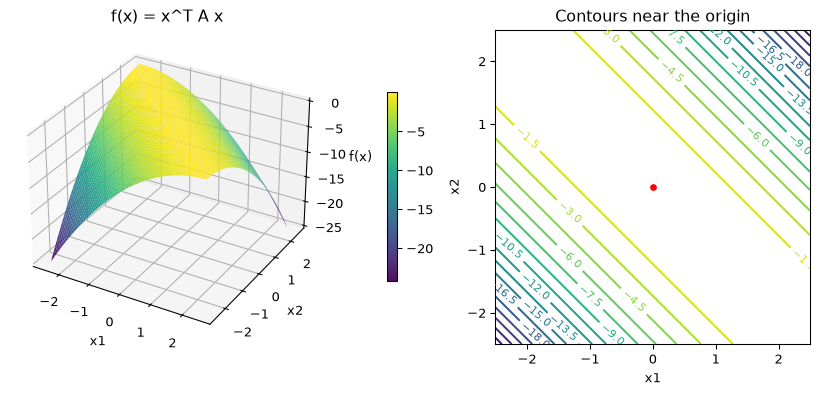

## Shape of an Indefinite Function

- For our $A = \begin{bmatrix} -6 & 1 \\ 1 & 0\end{bmatrix}$
- No maxima or minima since indefinite

eigs(A) = [-6.16227766  0.16227766]

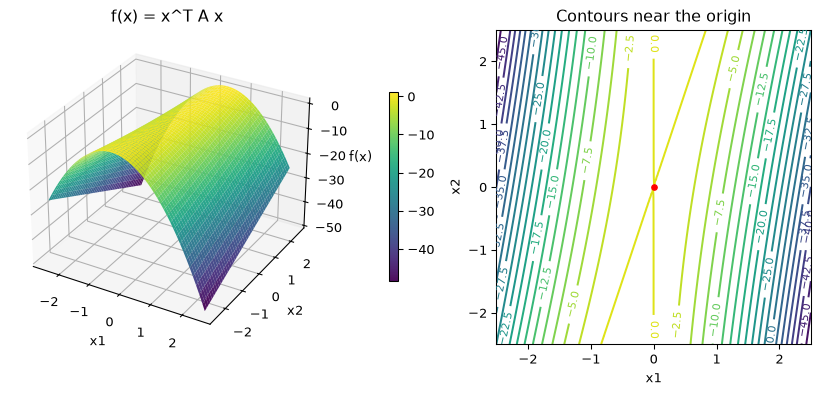

## Applications

- Many useful places for quadratic forms in economics
  - Second order approximations of functions (Taylor series) in macro
  - Checking sufficient conditions in optimization problems in micro
  - Least squares problems in statistics and ML, later in this lecture
  - Covariance matrices in econometrics, which are positive semi-definite by construction: next
- With nonlinear functions can look at a local quadratic approximation to understand local behavior and sufficiency of solutions

# Cholesky and Covariance Matrices

## Cholesky Decomposition

- A symmetric positive definite matrix has a symmetric version of the LU, with the same triangular factor on both sides
- Called a Cholesky decomposition: $A = L L^{\top}$ for a lower triangular matrix $L$.
- Equivalently, could find $A = U^{\top} U$ for an upper triangular matrix $U$

In [15]:
A = np.array([[1, 2],
              [2, 5]])
L = cholesky(A, lower=True) # lower=False gives the upper factor
print(L)
print(f"L*L^T =\n{L @ L.T}")

[[1. 0.]
 [2. 1.]]
L*L^T =
[[1. 2.]
 [2. 5.]]

## Solving Positive Definite Systems

In [16]:
A = np.array([[1, 2],
              [2, 5]])
b = np.array([1, 4])
print(solve(A, b, assume_a="pos")) # uses cholesky internally

L = cholesky(A, lower=True)
y = solve_triangular(L, b, lower=True)
x = solve_triangular(L.T, y, lower=False)
print(x)

[-3.  2.]
[-3.  2.]

## Cholesky for Covariance Matrices

- Covariance matrices are positive-definite, semi-definite if degenerate
- Key property of Gaussian random variables:
  - $X \sim {\mathcal{N}}(\mu, \Sigma)$ for $\mu \in {\mathbb{R}}^N, \Sigma \in {\mathbb{R}}^{N \times N}$
  - $X = \mu + A Z$ for $Z \sim {\mathcal{N}}(0_N, I_N)$ where $A A^{\top} = \Sigma$
- That is, $A$ is the Cholesky decomposition of the covariance matrix
- Simulate correlated shocks: draw independent ones and multiply by $A$

## Built-in Multivariate Normal

- Check the sample mean and covariance against $\mu$ and $\Sigma$ with a norm

In [17]:
mu = np.array([1.0, 2.0])
Sigma = np.array([[1.0, 0.8],
                  [0.8, 2.0]])
N = 10000
X = np.random.multivariate_normal(mu, Sigma, size=N)
print(f"mean =\n{np.mean(X, axis=0)}")
print(f"cov =\n{np.cov(X, rowvar=False)}")
print(f"||mean - mu|| = {norm(np.mean(X, axis=0) - mu):.4f}")
print(f"||cov - Sigma|| = {norm(np.cov(X, rowvar=False) - Sigma):.4f}")

mean =
[1.00890785 1.99134466]
cov =
[[1.01849699 0.81993007]
 [0.81993007 2.01162319]]
||mean - mu|| = 0.0124
||cov - Sigma|| = 0.0357

## Simulating with the Cholesky by Hand

L =
[[1.         0.        ]
 [0.8        1.16619038]]
||mean - mu|| = 0.0034
||cov - Sigma|| = 0.0239

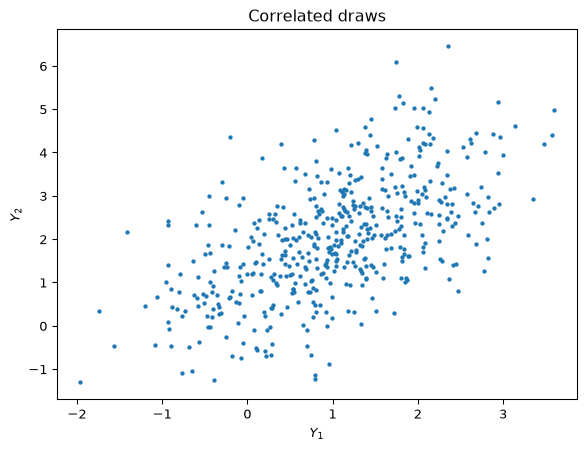

In [18]:
L = cholesky(Sigma, lower=True)
Z = np.random.randn(N, 2) # rows are draws
Y = mu + Z @ L.T # (mu + L Z) for each row
print(f"L =\n{L}")
print(f"||mean - mu|| = \
{norm(np.mean(Y, axis=0) - mu):.4f}")
print(f"||cov - Sigma|| = \
{norm(np.cov(Y, rowvar=False) - Sigma):.4f}")
fig, ax = plt.subplots()
ax.scatter(Y[:500, 0], Y[:500, 1], s=5)
ax.set(xlabel="$Y_1$", ylabel="$Y_2$",
       title="Correlated draws")
plt.show()

## Why it Works

- With $Y = \mu + L Z$ and $\operatorname{Var}(Z) = I$, we have ${\mathbb{E}}[Y] = \mu$ and

$$
\operatorname{Var}(Y) = L \operatorname{Var}(Z) L^{\top} = L I L^{\top} = L L^{\top} = \Sigma
$$

- Nothing here required $L$ to be triangular: any $A$ with $A A^{\top} = \Sigma$ works
  - The symmetric square root $\Sigma^{1/2} = Q \Lambda^{1/2} Q^{\top}$ from the eigendecomposition $\Sigma = Q \Lambda Q^{\top}$ is another choice
  - The Cholesky is the cheapest to compute and to apply since it is triangular
- If $\Sigma$ is only positive semi-definite the Cholesky may fail, but a rank-deficient $A$ still exists

# Least Squares and the Normal Equations

## Least Squares

Given a matrix $X \in {\mathbb{R}}^{N \times M}$ and a vector $y \in {\mathbb{R}}^N$, we want to find $\beta \in {\mathbb{R}}^M$ such that

$$
\begin{aligned}
\min_{\beta} &||y - X \beta||^2, \text{ that is,}\\
\min_{\beta} &\sum_{n=1}^N (y_n - X_n \cdot \beta)^2
\end{aligned}
$$

Where $X_n$ is n’th row. Take FOCS and rearrange to get

$$
(X^{\top} X) \beta =  X^{\top} y
$$

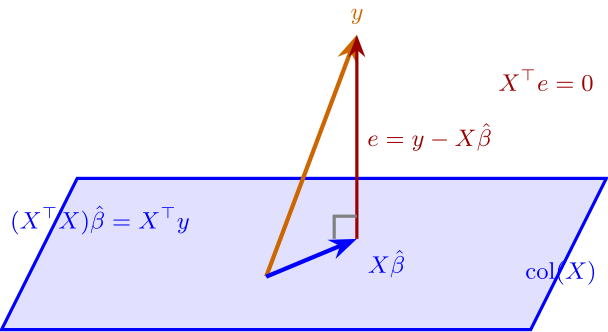

## Solving the Normal Equations

- The $X$ is often referred to as the “design matrix” and $X^{\top} X$ as the Gram matrix of the features (columns)

- Can form $A = X^{\top} X$ and $b = X^{\top} y$ and solve $A \beta = b$.

  - Or invert $X^{\top} X$ to get

  $$
  \beta = (X^{\top} X)^{-1} X^{\top} y
  $$

  - Note that $X^{\top} X$ is symmetric and, if $X$ is full-rank, positive definite

- The Hessian of $||y - X \beta||_2^2$ is $2 X^{\top} X$: positive definite when $X$ is full rank, so the normal equations give the unique minimum

## Solving Regression Models in Practice

- `lstsq` better algorithms (more numerically stable, same “order”, possibly slightly slower)
- One algorithm uses another factoring, the QR decomposition: $X = Q R$ for $Q$ orthogonal and $R$ upper triangular. See [QR Decomposition](https://python.quantecon.org/qr_decomp.html)
  - Undergrad suffering through matrix algebra classes: LU decomposition is Gaussian elimination, QR decomposition is Gram-Schmidt orthogonalization
- Stata also uses a $Q R$ decomposition under the hood.
- For applied work, use Stata, R, or `statsmodels` (integrates with `pandas` and `seaborn`)
  - See [statsmodels docs](https://www.statsmodels.org/dev/example_formulas.html) for R-style notation and [QuantEcon OLS Notes](https://python.quantecon.org/ols.html)
- For well conditioned problems (i.e., $\kappa(X^{\top} X)$ small), a Cholesky decomposition on $X^{\top}X$ then solving $(X^{\top}X) \beta = X^{\top}y$ may be faster but less numerically stable. A useful alternative in some “big data” cases when stata is insufficient.

## Example of LLS using Scipy

In [20]:
N, M = 100, 5
X = np.random.randn(N, M)
beta = np.random.randn(M)
y = X @ beta + 0.05 * np.random.randn(N)
beta_hat, residuals, rank, s = scipy.linalg.lstsq(X, y)
print(f"beta =\n {beta}\nbeta_hat =\n{beta_hat}")

beta =
 [-2.10378865  1.08556707 -2.78329393 -0.68383148  2.16714994]
beta_hat =
[-2.10292981  1.08372188 -2.77870538 -0.67543023  2.17412533]

## Solving using the Normal Equations

Or we can solve it directly. Provide matrix structure (so it can use a Cholesky)

In [21]:
XX = X.T @ X
Xy = X.T @ y
beta_hat = solve(XX, Xy, assume_a="pos")
# beta_hat = solve(X.T @ X, X.T @ y, assume_a="pos")
print(f"beta =\n {beta}\nbeta_hat =\n{beta_hat}")

beta =
 [-2.10378865  1.08556707 -2.78329393 -0.68383148  2.16714994]
beta_hat =
[-2.10292981  1.08372188 -2.77870538 -0.67543023  2.17412533]

# Collinearity and Identification

## Collinearity in “Tall” Matrices

- Tall ${\mathbb{R}}^{N\times M}$ “design matrices” have $N > M$ and are “overdetermined”
- The rank of a matrix is full rank if all columns are linearly independent
- You can only identify $M$ parameters with $M$ linearly independent columns

In [22]:
X = np.array([[1, 2],
              [2, 5],
              [3, 7]]) # 3 observations, 2 variables
X_col = np.array([[1, 2],
                  [2, 4],
                  [3, 6]]) # all proportional
print(f"rank(X) = {matrix_rank(X)}, rank(X_col) = {matrix_rank(X_col)}")

rank(X) = 2, rank(X_col) = 1

## Collinearity and Estimation

- The condition number gets larger with some operations
- If $X$ is not full rank, then $X^{\top} X$ is not invertible. For example:

In [23]:
print(f"cond(X) = {cond(X)}, cond(X'*X)={cond(X.T@X)}, cond(X_col'*X_col)={cond(X_col.T@X_col)}")

cond(X) = 53.097391448540385, cond(X'*X)=2819.3329786399063, cond(X_col'*X_col)=1.2999933999712892e+16

- Note that when you start doing operations on matrices, numerical error creeps in, so you will not get an exact number
- The rule-of-thumb with condition numbers is that if it is $1\times 10^k$ then you lose about $k$ digits of precision.
- Given the singular matrix, this means a continuum of $\beta$ will solve the problem

## `lstsq` Solves it? Careful on Interpretation!

- Since $X_{\text{col}}^{\top} X_{\text{col}}$ is singular, we cannot use `solve(X.T@X, X.T@y)`
- But what about `lstsq` methods?
- As you will see, this gives an answer. Interpretation is more subtle
- The key is that in the case of non-full rank, you cannot identify individual parameters
  - Related to “Identification” in econometrics
  - Having low residuals is not enough to conclude anything about identification of parameters

In [24]:
y = np.array([5.0, 10.1, 14.9])
beta_hat, residuals, rank, s = scipy.linalg.lstsq(X_col, y)
print(f"beta_hat_col = {beta_hat}")
print(f"rank={rank}, cols={X_col.shape[1]}, norm(X_col @ beta_hat - y)={norm(X_col @ beta_hat - y)}")

beta_hat_col = [0.99857143 1.99714286]
rank=1, cols=2, norm(X_col @ beta_hat - y)=0.13887301496588172

## Fat Design Matrices

- Fat ${\mathbb{R}}^{N\times M}$ “design matrices” have $N < M$ and are “underdetermined”
- Less common in econometrics, but useful to understand the structure
- A continuum of $\beta \in {\mathbb{R}}^M$ solve this problem: an affine subspace of dimension $M - \operatorname{rank}(X)$

In [25]:
X = np.array([[1, 2, 3],
              [0, 5, 7]]) # 2 rows, 3 variables
y = np.array([5, 10])
beta_hat, residuals, rank, s = scipy.linalg.lstsq(X, y)
print(f"beta_hat = {beta_hat}, rank={rank}")
print(f"norm(X @ beta_hat - y) = {norm(X @ beta_hat - y):.2g}")

beta_hat = [0.8 0.6 1. ], rank=2
norm(X @ beta_hat - y) = 2.5e-15

## Which Solution?

- Residuals are zero here because there are enough parameters to fit perfectly (i.e., it is underdetermined)
- Given the multiple solutions, the `lstsq` is giving

$$
\min_{\beta} ||\beta||_2^2 \,\text{s.t.}\,X \beta = y
$$

- i.e., the “smallest” coefficients which interpolate the data exactly
- Which trivially fulfills the OLS objective: $\min_{\beta} ||y - X \beta||_2^2$

## Careful Interpreting Underdetermined Solutions

- Useful and common in ML, but be **very** careful when interpreting for economics
  - Tight connections to Bayesian versions of statistical tests
  - But until you understand econometrics and “identification” well, **stick to full-rank matrices**
  - **Advanced topics:** search for “Regularization”, “Ridgeless Regression” and “Benign Overfitting in Linear Regression.”

# Regularization

## Recall a Positive Semi-Definite Function

- Flip the sign of the negative semi-definite shape from earlier in this lecture: $A = \begin{bmatrix} 1 & 1 \\ 1 & 1\end{bmatrix}$ is positive semi-definite with multiple minima along a line!

eigenvalues of A: [2.+0.j 0.+0.j]

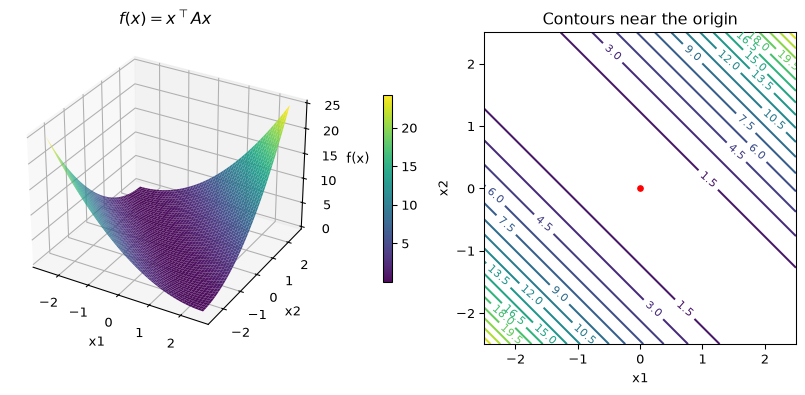

## Fudge the Diagonal?

- Replace with $A = A + \lambda I$ for $\lambda$ very small (e.g., $10^{-5}$)
- Now unique minima at $(0, 0)$

eigenvalues of A: [2.00001e+00+0.j 1.00000e-05+0.j]

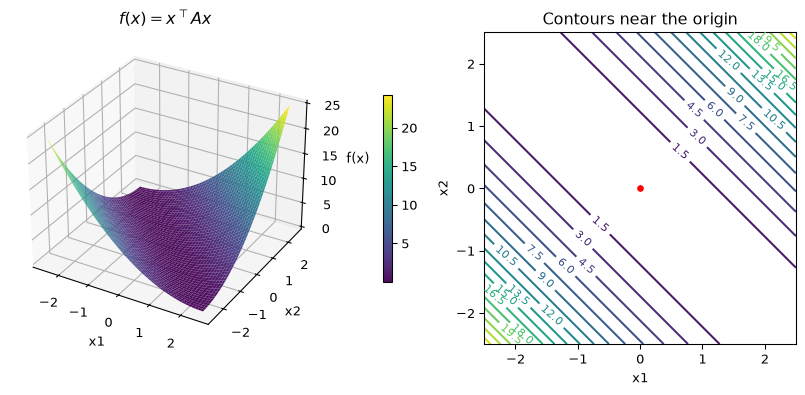

## Motivating this Fudge

- Previously solved $\min_x\left\{x^{\top} A x\right\}$, which only has a unique solution if $A$ is positive definite.

- Replace with

  $$
  \min_x\left\{x^{\top} A x+ \lambda ||x||_2^2\right\}
  $$

  - i.e., penalize solutions by the euclidean length of $x$, called a “ridge” term
  - Could instead penalize by different norms, e.g. $||x||_1$ is called LASSO

- What are the first order conditions? Lets look at least squares

## Ridge Regression

- More generally, for OLS think of the following

  $$
  \min_{\beta}\left\{ ||y - X \beta||_2^2 + \lambda ||\beta||_2^2\right\}
  $$

- Take the FOCs and rearrange to get

  $$
  (X^{\top} X + \lambda I) \beta =  X^{\top} y
  $$

  - Note: if $X^{\top}X$ is not full rank (i.e., has a zero eigenvalue) then the addition of the $\lambda$ term helps make things strictly positive definite
  - Sometimes you need to do this to overcome nearly collinear data or numerical approximations, even when it should be technically positive definite

## Ridgeless Regression

- Recall statement that `lstsq` will return **some** solution even if not full rank.

- We said that in the case where the data could be fit exactly

  - One can interpret the solution as $\min_{\beta} ||\beta||_2^2 \,\text{s.t.}\,X \beta = y$
  - Interpretation: this is the **min-norm** solution which fits the data with the “smallest” $\beta$

- Can show this is the limit of a ridge regression (i.e., “ridgeless”)

  $$
  \lim_{\lambda \to 0}\min_{\beta}\left\{ ||y - X \beta||_2^2 + \lambda ||\beta||_2^2\right\}
  $$

## Regularization in ML

- In ML, with rich data sources there are often many possible ways to explain the data
- Economists often avoid this like the plague, and make assumptions to ensure perfect identification
  - Identification arguments ensure positive definiteness of OLS, etc.
- As data becomes richer, it becomes hard to write down models with only a single explanation
  - Regularization lets you bias your solution towards ones with certain properties
- There are Bayesian interpretations of all of these approaches
- If you have a strict saddlepoint, then regularization probably isn’t the answer